In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(42)

# --- Parameters for 7GB RAM Safety ---
num_normal_sequences = 500
num_anomalous_sequences = 100
sequence_length = 50  # Memory-friendly step count
num_features = 5      # [packet_count, byte_transfer, duration, protocol, flags]

In [2]:
def generate_normal_sequence(seq_len, num_feat):
    sequence = []
    for _ in range(seq_len):
        packet_count = np.random.randint(1, 100)
        byte_transfer = np.random.randint(1000, 100000)
        duration = np.random.uniform(0.1, 60.0)
        protocol_type = np.random.randint(0, 4) 
        flags = np.random.randint(0, 8)       
        sequence.append([packet_count, byte_transfer, duration, protocol_type, flags])
    return np.array(sequence)

def generate_anomalous_sequence(seq_len, num_feat):
    sequence = []
    anomaly_type = np.random.choice(['high_volume', 'long_duration', 'unusual_protocol', 'suspicious_flags'], 1)[0]
    for i in range(seq_len):
        # Base normal values
        p, b, d, pr, f = np.random.randint(1, 100), np.random.randint(1000, 100000), np.random.uniform(0.1, 60.0), np.random.randint(0, 4), np.random.randint(0, 8)
        # Inject the anomaly
        if anomaly_type == 'high_volume' and i % 5 == 0: p *= 15; b *= 15
        elif anomaly_type == 'long_duration' and i % 10 == 0: d *= 8
        elif anomaly_type == 'unusual_protocol' and i % 7 == 0: pr = np.random.randint(4, 6)
        elif anomaly_type == 'suspicious_flags' and i % 3 == 0: f = np.random.choice([1, 2, 4, 8])
        sequence.append([p, b, d, pr, f])
    return np.array(sequence)

# Create the datasets
normal_data = [generate_normal_sequence(sequence_length, num_features) for _ in range(num_normal_sequences)]
anomalous_data = [generate_anomalous_sequence(sequence_length, num_features) for _ in range(num_anomalous_sequences)]

# Combine and Label (0 = Normal, 1 = Anomaly)
all_data = np.concatenate((np.array(normal_data), np.array(anomalous_data)), axis=0)
all_labels = np.concatenate((np.zeros(num_normal_sequences), np.ones(num_anomalous_sequences)), axis=0)


In [3]:
# Flatten to scale, then reshape back for the LSTM
reshaped_data = all_data.reshape(600 * sequence_length, num_features)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(reshaped_data).reshape(600, sequence_length, num_features)

# Final Split
X_train, X_test, y_train, y_test = train_test_split(scaled_data, all_labels, test_size=0.2, random_state=42)

print(f"✅ Data Ready! Training samples: {X_train.shape[0]}")
print(f"Each sample is a sequence of {X_train.shape[1]} events with {X_train.shape[2]} features.")

✅ Data Ready! Training samples: 480
Each sample is a sequence of 50 events with 5 features.


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build the Sequential model
model = Sequential([
    # 1. LSTM Layer: Captures the 'memory' of the 50-step sequence
    # input_shape = (sequence_length, num_features)
    LSTM(32, input_shape=(50, 5), return_sequences=False), 
    
    # 2. Dropout: A safety layer to prevent the model from 'memorizing' noise
    Dropout(0.2),
    
    # 3. Dense Layers: The reasoning part of the brain
    Dense(16, activation='relu'),
    
    # 4. Output Layer: Sigmoid gives a probability between 0 (Normal) and 1 (Anomaly)
    Dense(1, activation='sigmoid')
])

# Compile the model with binary_crossentropy for our 0/1 classification
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Check the parameter count
model.summary()

2026-03-09 13:57:31.431297: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 13:57:31.470703: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 13:57:31.502308: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-09 13:57:31.502353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-09 13:57:31.503201: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 32)                4864      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 5409 (21.13 KB)
Trainable params: 5409 (21.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
import sys
# This installs it EXACTLY where your current notebook is looking
!{sys.executable} -m pip install tensorflow==2.15.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 102.2 kB/s eta 0:00:0000:0100:33
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 361.8 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 196.8 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 177.0 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 108.7 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 81.2 kB/s eta 0:00:0000:0100:09m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.3 kB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 101.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.9 kB/s eta 0:00:0000:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 73.2 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 164.0 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━

In [7]:
# Train for 10 'epochs' (rounds through the data)
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=16, 
                    validation_data=(X_test, y_test))

print("\n🚀 Training complete! Your LSTM is now detecting network anomalies.")

Epoch 1/10
30/30 [==============================] - 2s 19ms/step - loss: 0.5407 - accuracy: 0.8417 - val_loss: 0.5481 - val_accuracy: 0.8000
Epoch 2/10
30/30 [==============================] - 0s 7ms/step - loss: 0.4476 - accuracy: 0.8417 - val_loss: 0.5085 - val_accuracy: 0.8000
Epoch 3/10
30/30 [==============================] - 0s 7ms/step - loss: 0.4572 - accuracy: 0.8417 - val_loss: 0.5108 - val_accuracy: 0.8000
Epoch 4/10
30/30 [==============================] - 0s 6ms/step - loss: 0.4401 - accuracy: 0.8417 - val_loss: 0.5141 - val_accuracy: 0.8000
Epoch 5/10
30/30 [==============================] - 0s 7ms/step - loss: 0.4464 - accuracy: 0.8417 - val_loss: 0.5084 - val_accuracy: 0.8000
Epoch 6/10
30/30 [==============================] - 0s 6ms/step - loss: 0.4364 - accuracy: 0.8417 - val_loss: 0.5153 - val_accuracy: 0.8000
Epoch 7/10
30/30 [==============================] - 0s 8ms/step - loss: 0.4431 - accuracy: 0.8417 - val_loss: 0.5057 - val_accuracy: 0.8000
Epoch 8/10
30/30 [=

In [8]:
# 1. Train the model
# validation_data allows us to see how it performs on the 20% of data it hasn't seen yet
history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=16, 
    validation_data=(X_test, y_test)
)

print("\n🚀 Training complete! Your LSTM 'Memory' is now online.")

Epoch 1/10
30/30 [==============================] - 0s 9ms/step - loss: 0.4299 - accuracy: 0.8417 - val_loss: 0.4878 - val_accuracy: 0.8000
Epoch 2/10
30/30 [==============================] - 0s 8ms/step - loss: 0.4256 - accuracy: 0.8417 - val_loss: 0.4696 - val_accuracy: 0.8000
Epoch 3/10
30/30 [==============================] - 0s 8ms/step - loss: 0.4107 - accuracy: 0.8417 - val_loss: 0.4690 - val_accuracy: 0.8083
Epoch 4/10
30/30 [==============================] - 0s 7ms/step - loss: 0.3943 - accuracy: 0.8729 - val_loss: 0.3957 - val_accuracy: 0.8750
Epoch 5/10
30/30 [==============================] - 0s 8ms/step - loss: 0.3931 - accuracy: 0.8771 - val_loss: 0.4167 - val_accuracy: 0.8583
Epoch 6/10
30/30 [==============================] - 0s 8ms/step - loss: 0.3750 - accuracy: 0.8771 - val_loss: 0.4037 - val_accuracy: 0.8583
Epoch 7/10
30/30 [==============================] - 0s 8ms/step - loss: 0.3776 - accuracy: 0.8771 - val_loss: 0.4033 - val_accuracy: 0.8583
Epoch 8/10
30/30 [==

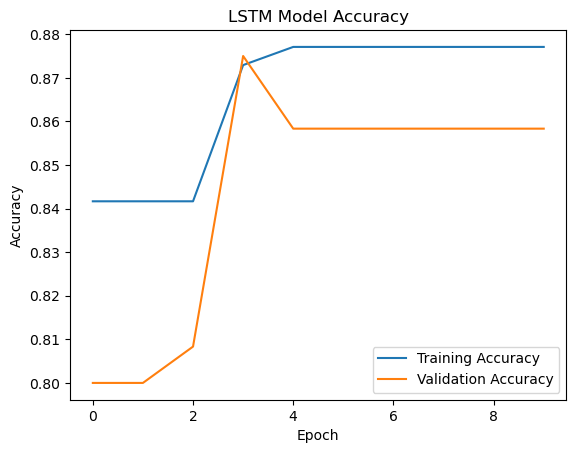

4/4 [==============================] - 0s 5ms/step - loss: 0.3998 - accuracy: 0.8583

✅ Test Accuracy: 85.83%


In [9]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Evaluate on the unseen test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {accuracy*100:.2f}%")

In [10]:
# 1. Generate a single new anomalous sequence (e.g., a High Volume attack)
new_attack = generate_anomalous_sequence(sequence_length, num_features)

# 2. Scale it using the same scaler we used for training
scaled_attack = scaler.transform(new_attack).reshape(1, sequence_length, num_features)

# 3. Predict!
prediction = model.predict(scaled_attack)
threat_score = prediction[0][0]

print(f"\n🕵️ Detection System Analysis:")
print(f"Threat Score: {threat_score:.4f}")
if threat_score > 0.5:
    print("🚨 ALERT: Anomaly Detected! Potential multi-stage attack.")
else:
    print("🟢 STATUS: Traffic appears normal.")

1/1 [==============================] - 0s 280ms/step

🕵️ Detection System Analysis:
Threat Score: 0.9828
🚨 ALERT: Anomaly Detected! Potential multi-stage attack.


In [11]:
# 1. Generate Class Predictions (0 or 1)
predictions = model.predict(X_test)
# We use a 0.5 threshold: >0.5 is an Anomaly, <=0.5 is Normal
predicted_labels = (predictions > 0.5).astype(int).flatten()

# 2. Compare the First 10 Results
print("Sample Predictions vs Actual Labels:")
for i in range(10):
    print(f"Sample {i+1}: Predicted={predicted_labels[i]}, Actual={int(y_test[i])}")

# 3. Save the Model for your CyberAI Portfolio
# Note: Ensure the 'models' directory exists in your work folder
model_path = 'lstm_anomaly_detector.keras'
model.save(model_path)
print(f"\n✅ Model saved successfully as {model_path}")

4/4 [==============================] - 0s 5ms/step
Sample Predictions vs Actual Labels:
Sample 1: Predicted=0, Actual=0
Sample 2: Predicted=0, Actual=0
Sample 3: Predicted=0, Actual=1
Sample 4: Predicted=0, Actual=0
Sample 5: Predicted=0, Actual=0
Sample 6: Predicted=0, Actual=0
Sample 7: Predicted=0, Actual=0
Sample 8: Predicted=0, Actual=0
Sample 9: Predicted=0, Actual=0
Sample 10: Predicted=0, Actual=0

✅ Model saved successfully as lstm_anomaly_detector.keras
